In [1]:
import tensorly as tl

tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == meta['session'][0]
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 26)


/tmp/ipykernel_377/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 14, 13)

In [35]:
from hoda.hoda import HODA
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues


hoda = HODA(
    rank=2,
    max_iter=256,
    tol=1e-8,
    init ='svd',
    shrinkage='lw',
    toeplitz=(1,2),
    taper=False,
    obj='rt',
    solver='lanczos',
    keep_train_info=True,
    verbose=True,
)




hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2, 2) ...


HODA(keep_train_info=True, rank=2, toeplitz=(1, 2), verbose=True)

In [36]:
hoda.train_info_

,F_tr,F_rt,mse,update
iteration,,,,
0.0,0.018440,0.000535,2.215449e-11,0.142729
1.0,0.083595,0.001449,1.963104e-11,0.121726
2.0,0.016104,0.000307,2.227911e-11,0.134059
3.0,0.020804,0.000758,2.103165e-11,0.147259
4.0,0.013122,0.000217,2.224595e-11,0.150706
...,...,...,...,...
251.0,0.048718,0.001051,2.194414e-11,0.131499
252.0,0.008872,0.000240,2.230399e-11,0.136017
253.0,0.046050,0.001054,2.173519e-11,0.133403


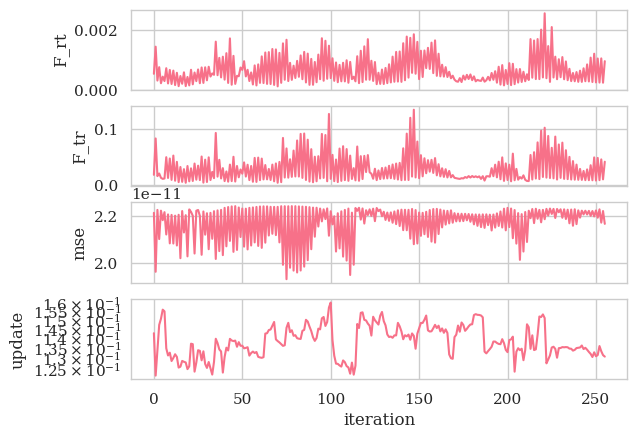

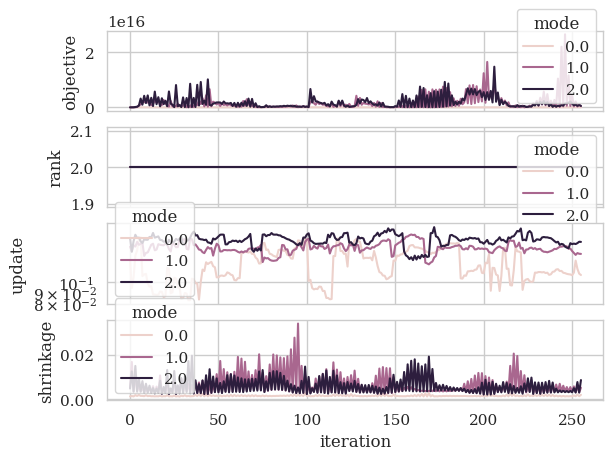

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.covariance import ledoit_wolf_shrinkage

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F_rt', ax=axs[0])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F_tr', ax=axs[1])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[2])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")

    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])


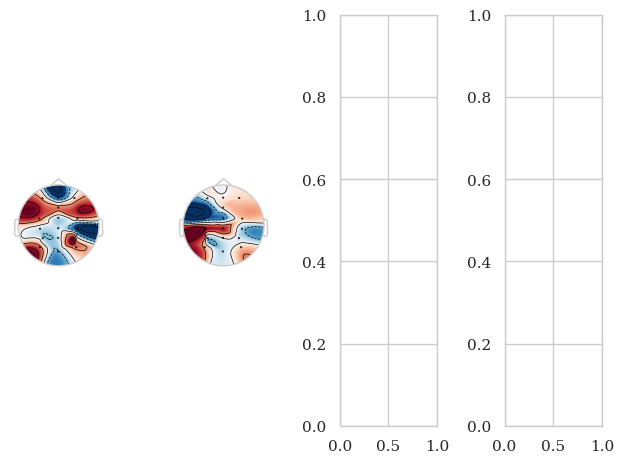

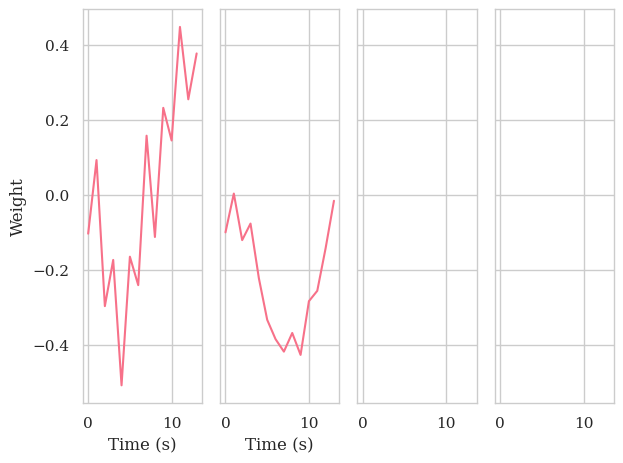

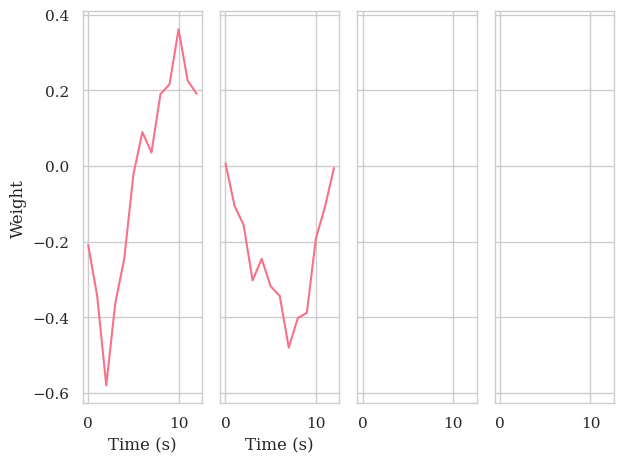

In [38]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');

n_row = int( np.ceil(hoda.rank_(2) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(2)):
    w = tl.to_numpy(hoda.scalings_[2][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


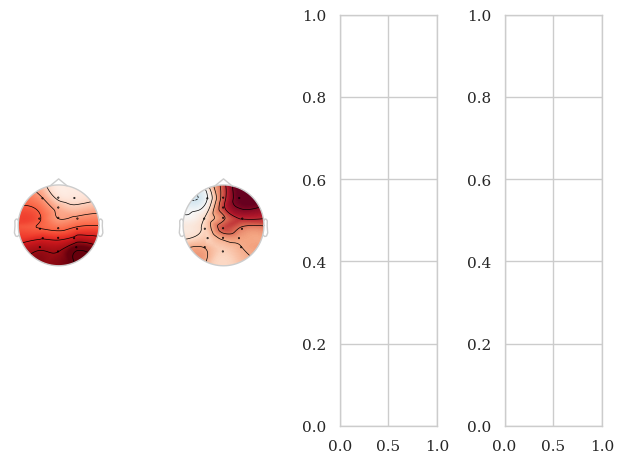

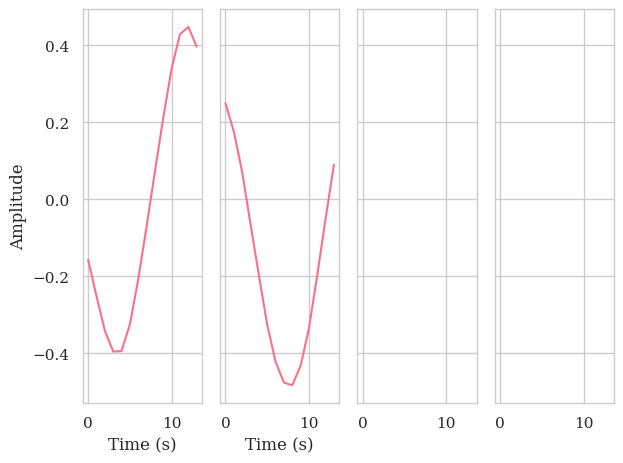

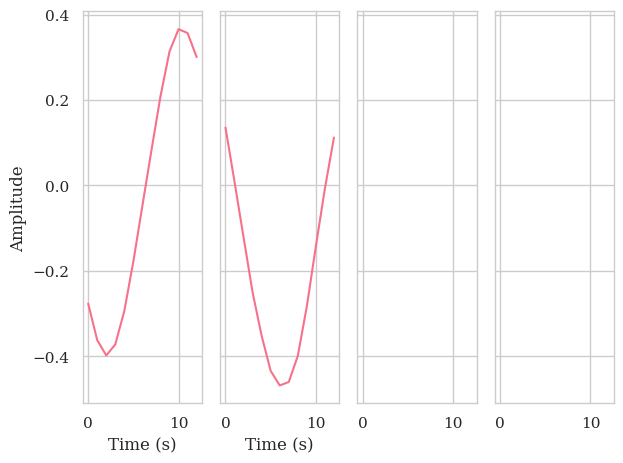

In [39]:
n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude')

n_row = int(np.ceil(hoda.rank_(2) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[2]
for i in range(hoda.rank_(2)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');

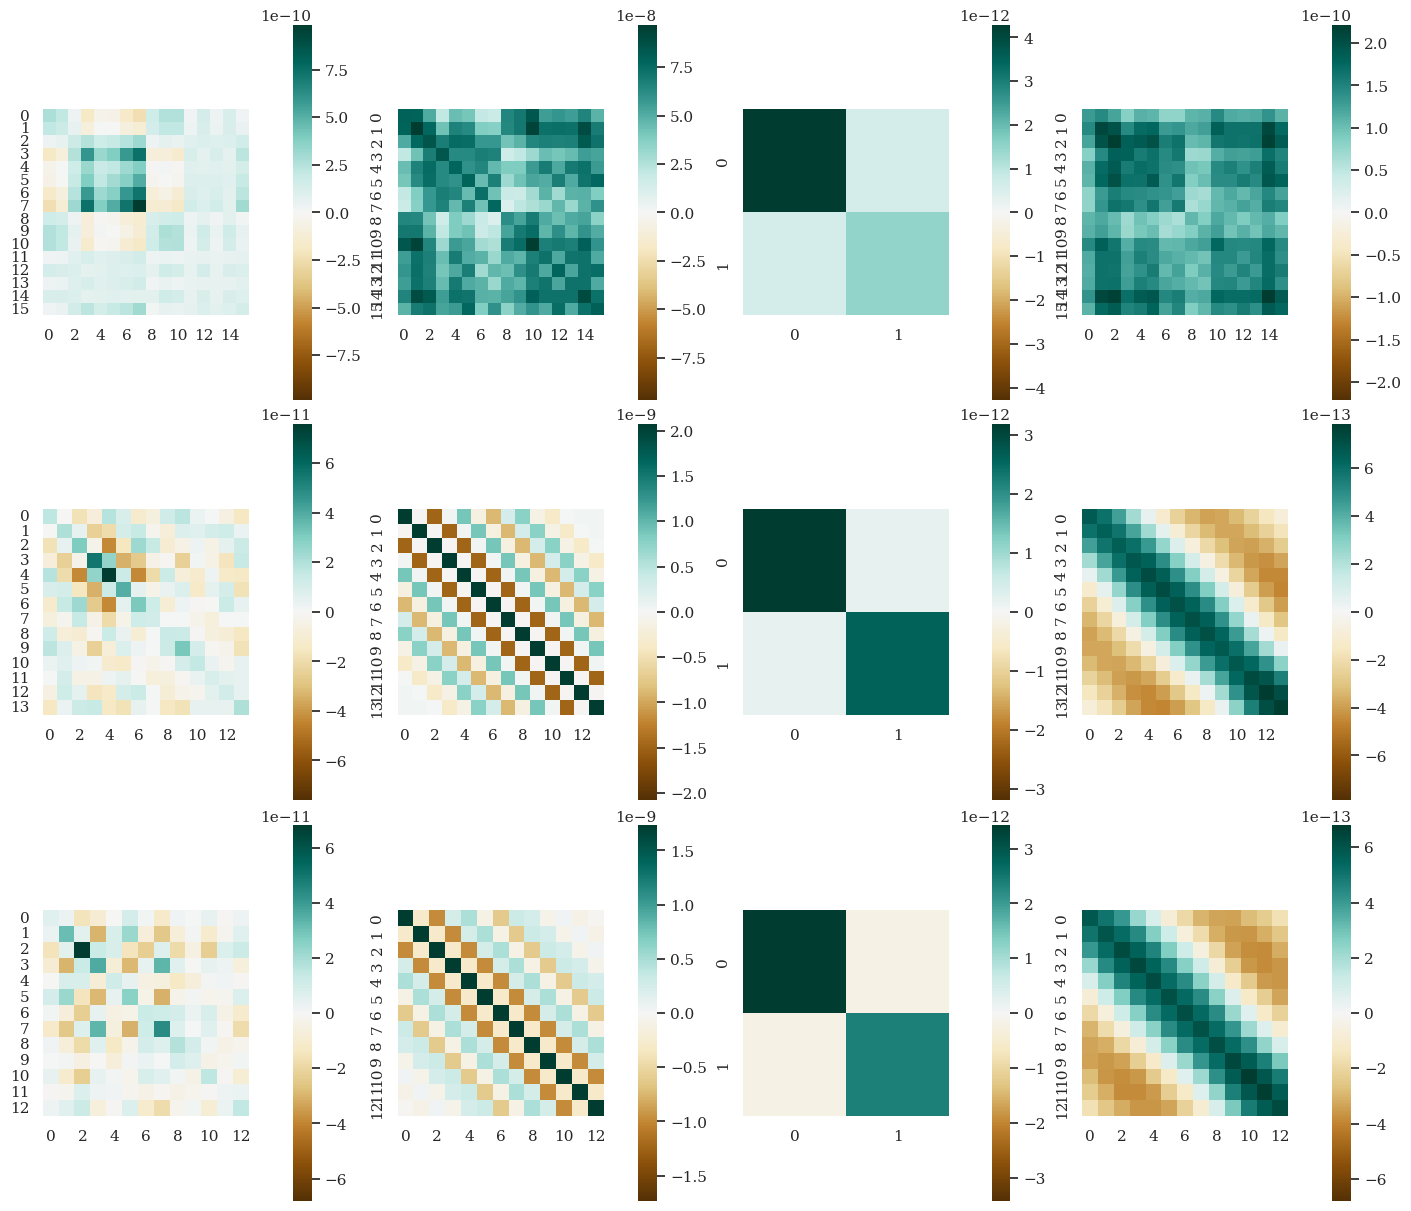

In [40]:
fig, axs = plt.subplots(3,4,layout='constrained',figsize=(14,12))
for k in range(3):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov =  tl.to_numpy(hoda.cov_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [41]:
Xt = hoda.transform(X)
Xt

array([[[[-1.33309497e-06,  1.42176383e-06],
         [ 1.41560166e-06, -2.06570715e-06]],

        [[-1.43394657e-06,  1.31053484e-06],
         [ 1.20905538e-06,  7.45648057e-07]]],


       [[[ 3.88543801e-06, -3.55615167e-06],
         [-3.11374512e-06, -2.55889469e-06]],

        [[ 7.87801341e-07, -4.32222615e-07],
         [-2.96487898e-07, -1.13913855e-06]]],


       [[[-5.83127512e-06, -9.65613463e-09],
         [-3.54702570e-07,  6.17423504e-06]],

        [[ 1.62951945e-06, -4.88852008e-07],
         [-1.36516960e-07, -1.39268105e-06]]],


       ...,


       [[[-4.91561375e-06, -1.14566194e-06],
         [-1.66991768e-06,  4.26164796e-06]],

        [[-3.34578725e-06,  7.04386922e-07],
         [ 6.90614879e-07,  3.55108425e-06]]],


       [[[ 2.22722010e-06,  3.44363923e-06],
         [ 3.87622278e-06, -1.35225118e-06]],

        [[ 1.35683492e-06,  2.65185230e-06],
         [ 2.83538065e-06, -1.95763562e-06]]],


       [[[ 1.50200082e-06, -3.00621651e-06],
         [-

In [42]:
from hoda.hoda import f_oneway
from hoda.gpu_opt import combine_pvalues

import matplotlib
matplotlib.rcParams['axes.linewidth'] = 1
F, p = f_oneway(Xt,y)


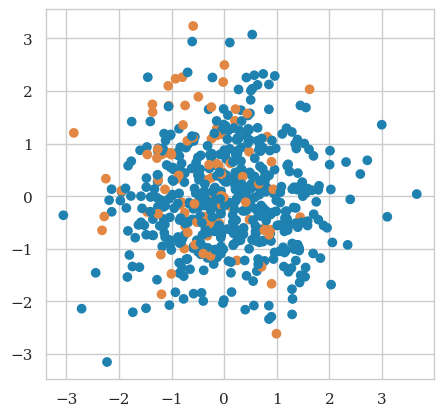

In [43]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


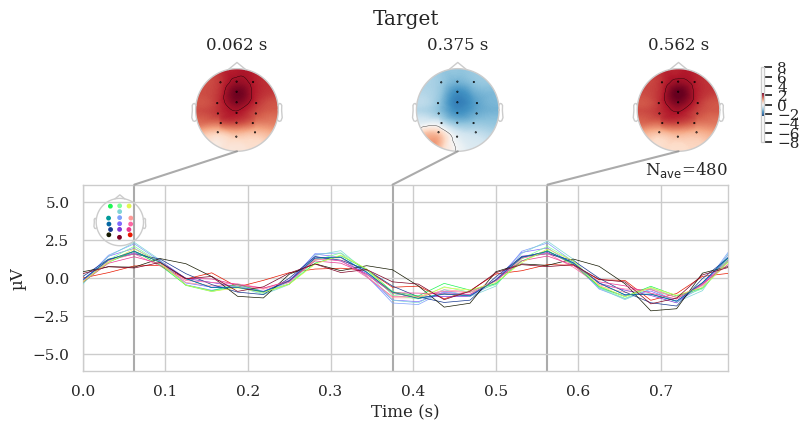

No projector specified for this dataset. Please consider the method self.add_proj.


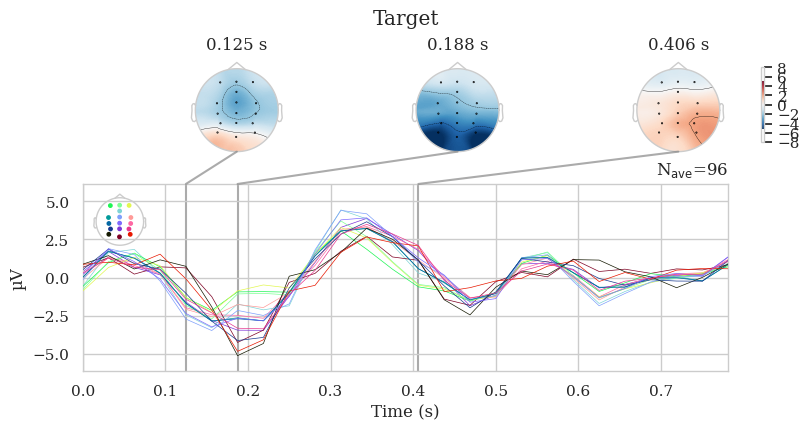

In [44]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_377/1426169175.py:4: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hankel_tensor_inv(hoda.inv_transform(hoda.transform(hankel_tensor(epochs.get_data())))))


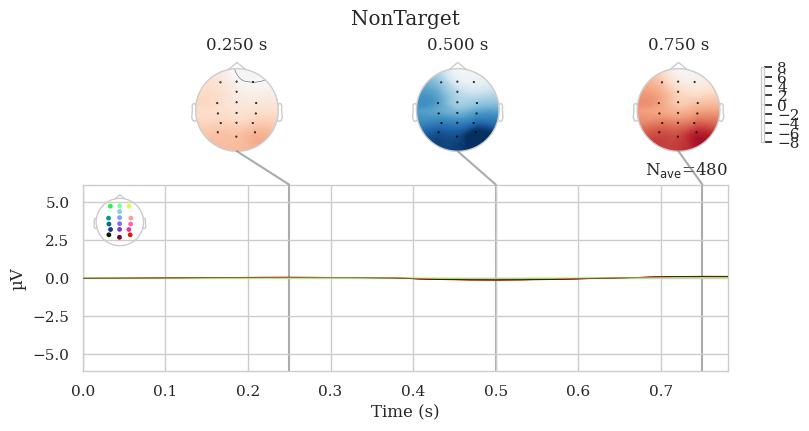

No projector specified for this dataset. Please consider the method self.add_proj.


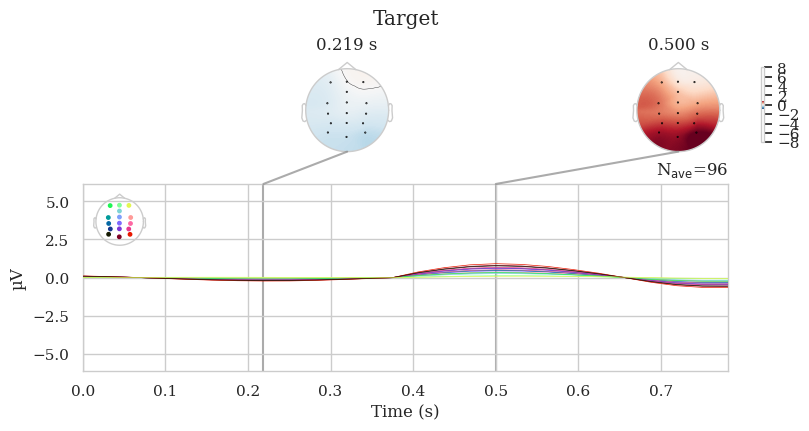

In [45]:
from hoda.tensorize import hankel_tensor, hankel_tensor_inv

epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hankel_tensor_inv(hoda.inv_transform(hoda.transform(hankel_tensor(epochs.get_data())))))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        _ = evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        _ = evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


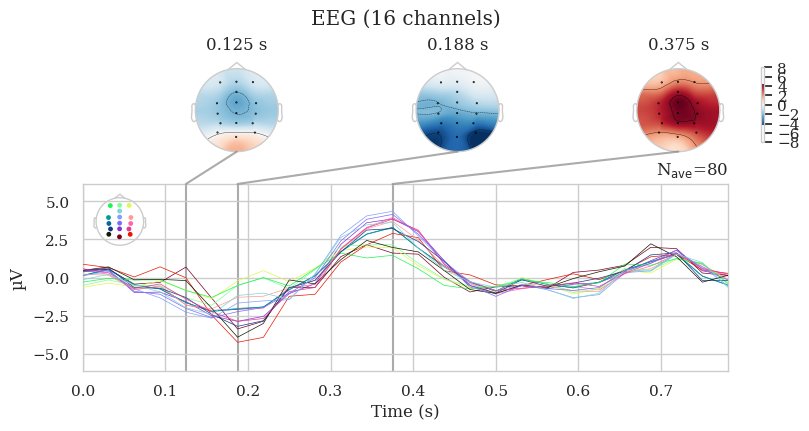

No projector specified for this dataset. Please consider the method self.add_proj.


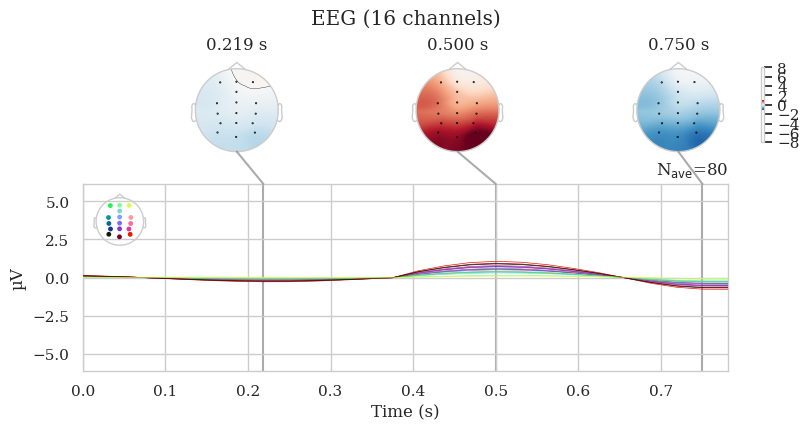

In [46]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)

No projector specified for this dataset. Please consider the method self.add_proj.


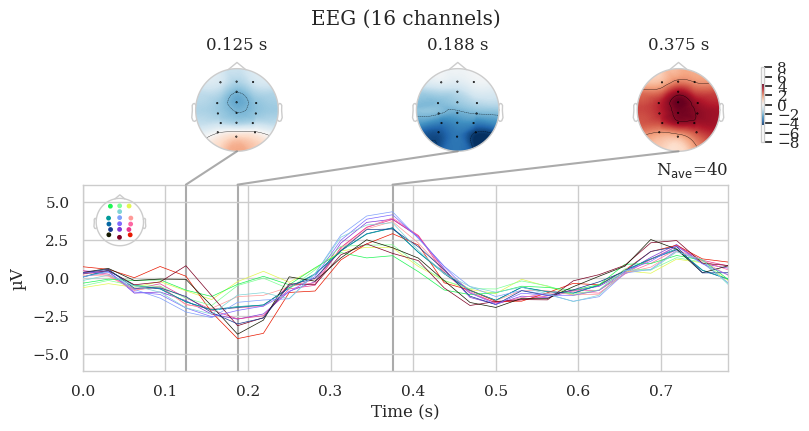

In [47]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)